# SOL Hourly Factor Research Regression

This notebook tests how SOL hourly returns move with contemporaneous crypto market factors, BTC volatility/risk proxies, hourly ETF market proxies, and slow macro variables aligned to the Binance hourly timeline. It is an explanatory research regression, so some predictors are same-hour factors rather than tradeable signals. Use the trading forecast notebook for strictly lagged, backtest-oriented signals.


## Setup and hourly data configuration


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from features import build_research_features
from load_data import load_market_data
from modeling import fit_regression_models
from plots import plot_correlation_matrix, plot_cumulative_returns, plot_regression_fit

time_interval = "1H"
coin_order = ["SOL", "BTC", "ETH", "BNB", "XRP", "DOGE", "SHIB", "PEPE"]
target = "SOL"
peer_coins = [coin for coin in coin_order if coin != target]
coin_colors = {
    "SOL": "purple",
    "BTC": "orange",
    "ETH": "grey",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
    "PEPE": "green",
}


## Load Binance hourly crypto data


In [2]:
# Load downloaded market data
market_data = load_market_data(project_root, time_interval, coin_order)

open_prices = market_data["open_prices"]
high_prices = market_data["high_prices"]
low_prices = market_data["low_prices"]
close_prices = market_data["close_prices"]
volume_from = market_data["volume_from"]
raw_returns = market_data["raw_returns"]
log_returns = market_data["log_returns"]
fred_features = market_data["fred_features"]
yfinance_log_returns = market_data["yfinance_log_returns"]
btc_funding = market_data["btc_funding"]
btc_dvol = market_data["btc_dvol"]
cumulative_returns = market_data["cumulative_returns"]
simple_cumulative_returns = market_data["simple_cumulative_returns"]


## Build hourly (log) returns and aligned external factors


In [3]:
print("Simple cumulative return:")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(simple_cumulative_returns.tail())
print()


Simple cumulative return:
coin                            SOL       BTC       ETH       BNB       XRP      DOGE      SHIB      PEPE
timestamp                                                                                                
2026-07-29 04:00:00+00:00 -0.560232 -0.014325 -0.403479 -0.011009  0.835258 -0.402692 -0.708386 -0.737799
2026-07-29 05:00:00+00:00 -0.558855 -0.012800 -0.401282 -0.009148  0.844090 -0.402184 -0.705845 -0.735885
2026-07-29 06:00:00+00:00 -0.556460 -0.007125 -0.398890 -0.006557  0.847317 -0.400660 -0.706480 -0.734928
2026-07-29 07:00:00+00:00 -0.555383 -0.005193 -0.397472 -0.005391  0.851732 -0.399052 -0.705845 -0.735885
2026-07-29 08:00:00+00:00 -0.557538 -0.007982 -0.400374 -0.007757  0.844939 -0.402692 -0.707751 -0.737799



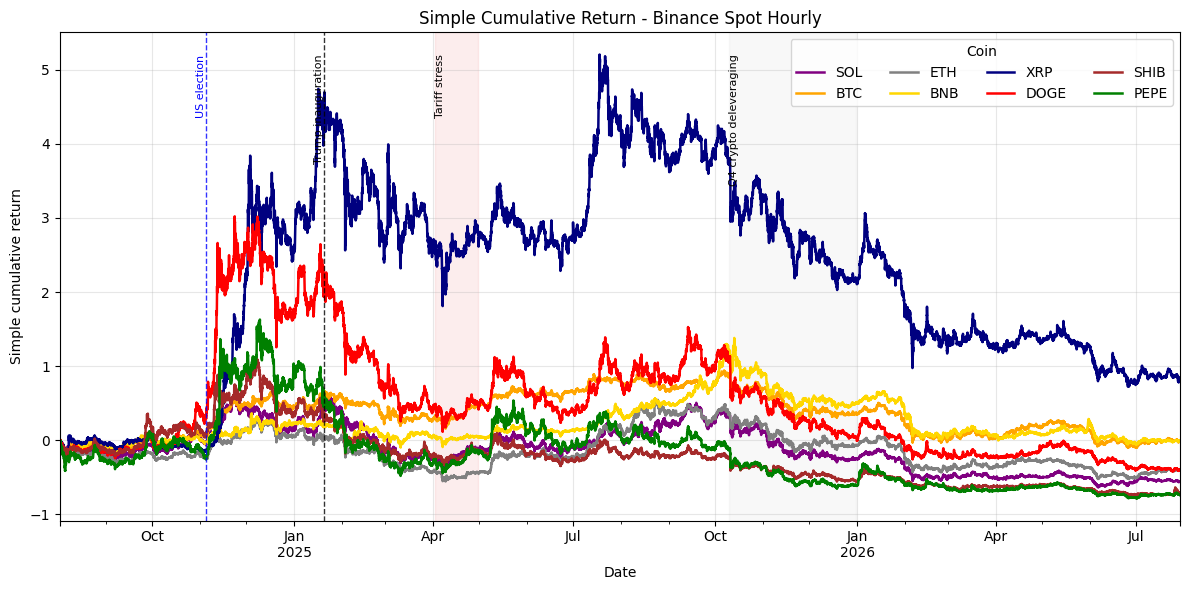

In [4]:
plot_cumulative_returns(
    simple_cumulative_returns,
    coin_colors,
    title="Simple Cumulative Return - Binance Spot Hourly",
    ylabel="Simple cumulative return",
    ncols=4,
)


## Build explanatory feature matrix


In [5]:
# Build same-hour feature matrix for explanatory fit testing
# - target SOL is the current hourly log return
# - broad market returns are same-hour features
# - SOL/BTC technical factors are same-hour descriptive features
# - this matrix explains co-movement and market state, not tradable forecasts
features, model_data = build_research_features(target, peer_coins, market_data)

print(f"Number of model features: {features.shape[1]}")
print()
print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(model_data.head(10))

print()
print("Dependent Variable is current-hour SOL log return.")
print("Predictors are same-hour explanatory features, including crypto returns, market proxies, macro context, funding, DVOL, and SOL/BTC technical state.")
print("This research matrix explains co-movement and market state. It is not a tradable forecast matrix.")

print("Predictors use Binance spot hourly OHLCV plus hourly yfinance ETF proxies.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Number of model features: 31

Model data:
                                SOL       BTC       ETH       BNB       XRP      DOGE      SHIB      PEPE  SOL_momentum_7h  SOL_momentum_14h  SOL_volatility_7h  SOL_volatility_14h  SOL_volume_change  SOL_range  BTC_volatility_14h  BTC_range  BTC_funding_rate_sum  BTC_DVOL_change  M2_30d_change  SOFR_change  DFF_change  QQQ  SPY  IEF  TLT  UUP  HYG  VXX  SOL_SMA12h  SOL_SMA26h  SOL_RSI_14h  SOL_BB_percent_b_20h
timestamp                                                                                                                                                                                                                                                                                                                                                                                                                    
2024-10-01 00:00:00+00:00  0.010957  0.003222  0.006355  0.007900  0.014291  0.013394  0.036876  0.014238        -0.009297        

In [6]:
print(features.isna().sum().sort_values(ascending=False).to_string())


M2_30d_change           1440
SOL_SMA26h                25
SOL_BB_percent_b_20h      19
IEF                       14
SPY                       14
TLT                       14
UUP                       14
QQQ                       14
SOL_RSI_14h               14
HYG                       14
VXX                       14
SOL_volatility_14h        13
BTC_volatility_14h        13
SOL_momentum_14h          13
SOL_SMA12h                11
SOL_volatility_7h          6
SOL_momentum_7h            6
SOFR_change                1
SOL_volume_change          1
BTC_DVOL_change            1
DFF_change                 1
BTC_range                  0
PEPE                       0
BTC                        0
SOL_range                  0
ETH                        0
BNB                        0
XRP                        0
DOGE                       0
SHIB                       0
BTC_funding_rate_sum       0


## Feature correlation diagnostics


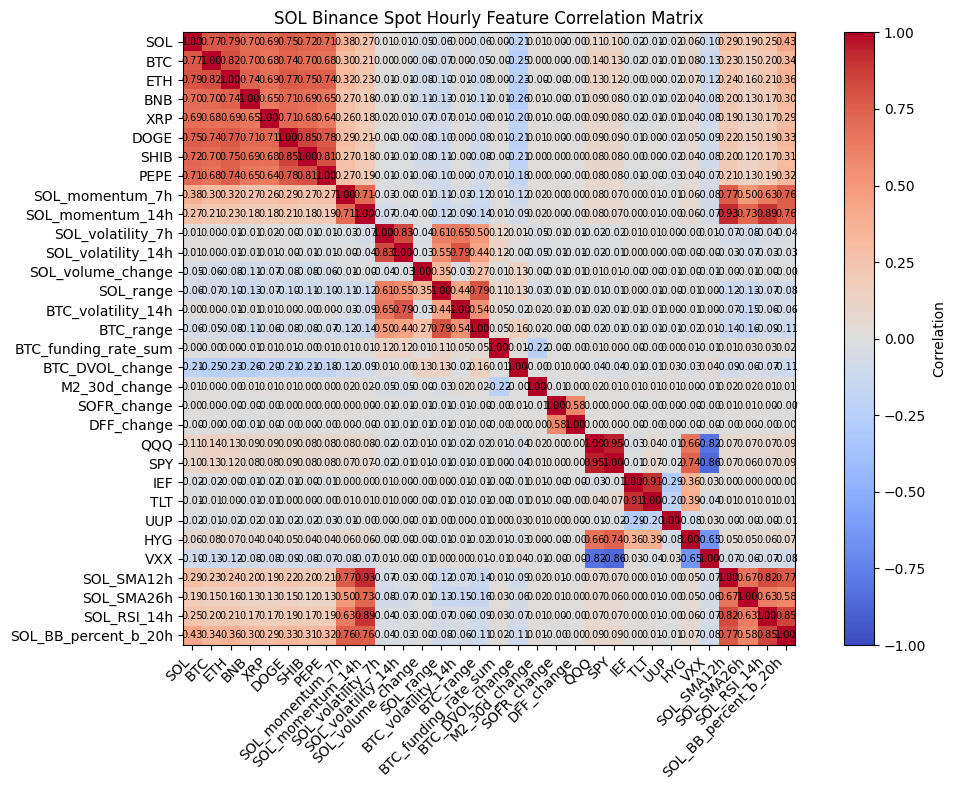

In [7]:
plot_correlation_matrix(model_data, "SOL Binance Spot Hourly Feature Correlation Matrix")


## Fit explanatory regression models


In [8]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
model_result = fit_regression_models(model_data, target, feature_columns)

feature_columns = model_result["feature_columns"]
train_data = model_result["train_data"]
test_data = model_result["test_data"]
X_train = model_result["X_train"]
X_test = model_result["X_test"]
y_train = model_result["y_train"]
y_test = model_result["y_test"]
model = model_result["model"]
y_pred = model_result["y_pred"]
ridge_model = model_result["ridge_model"]
ridge_y_pred = model_result["ridge_y_pred"]
elastic_net_model = model_result["elastic_net_model"]
elastic_net_y_pred = model_result["elastic_net_y_pred"]
model_accuracy_comparison = model_result["model_accuracy_comparison"]
model_comparison = model_result["model_comparison"]
elastic_net_coefficients = model_result["elastic_net_coefficients"]
elastic_net_selected_coefficients = model_result["elastic_net_selected_coefficients"]
metrics_by_model = model_accuracy_comparison.set_index("model")

print()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                    SOL   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     1140.
Date:                Wed, 05 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:46:29   Log-Likelihood:                 50587.
No. Observations:               12794   AIC:                        -1.011e+05
Df Residuals:                   12762   BIC:                        -1.009e+05
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0020

### Model comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [9]:
print("Model comparison")
print(model_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model comparison
     model      alpha  l1_ratio  nonzero_coef  train_r2  adj_train_r2  test_r2  adj_test_r2     rmse  prediction_corr  cv_r2_mean
       OLS        NaN       NaN            31  0.734634      0.733989 0.821659     0.819913 0.002589         0.907899    0.749392
     Ridge 100.000000       NaN            31  0.734505      0.733860 0.823419     0.821690 0.002576         0.908672    0.750000
ElasticNet   0.000100  0.500000            20  0.731910      0.731259 0.823893     0.822170 0.002573         0.909020    0.750904

ElasticNet selected coefficients
             feature  coefficient
                 BTC   0.00197784
                 ETH   0.00203309
                 BNB  0.000736804
                 XRP  0.000935202
                DOGE   0.00104501
                SHIB  0.000387992
                PEPE   0.00086565
     SOL_momentum_7h  0.000321641
    SOL_momentum_14h  8.51126e-05
  SOL_volatility_14h -1.52877e-05
   SOL_volume_change  3.64582e-06
           SOL_range 

## Model comparison and diagnostics


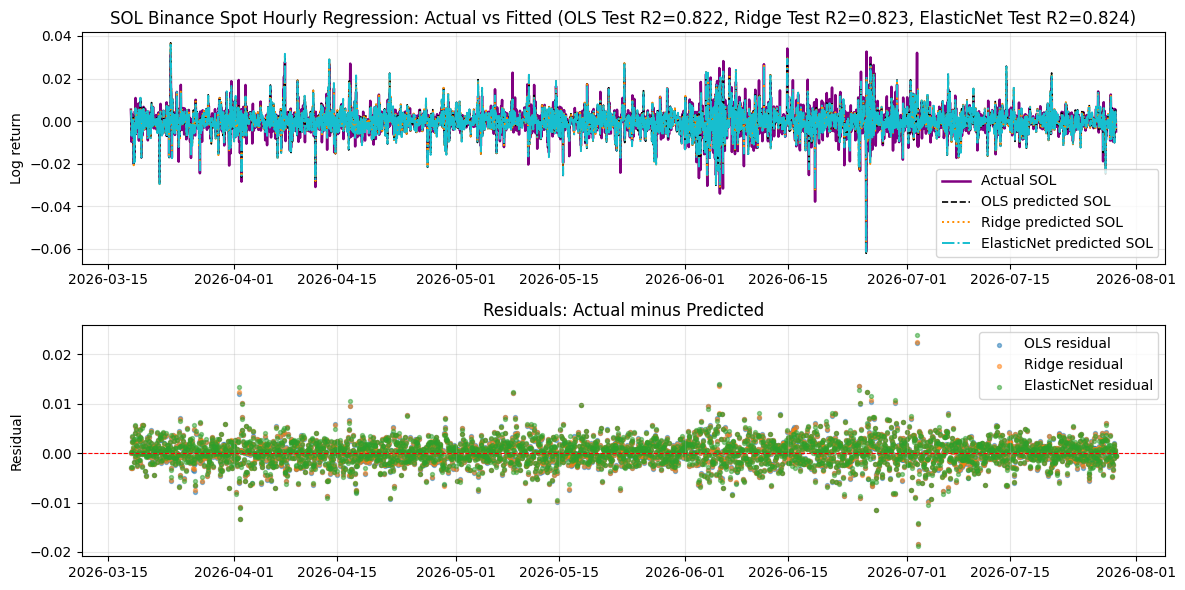

In [10]:
predictions = {
    "OLS": y_pred,
    "Ridge": ridge_y_pred,
    "ElasticNet": elastic_net_y_pred,
}
plot_regression_fit(
    test_data,
    y_test,
    predictions,
    target=target,
    target_color=coin_colors[target],
    title=(
        f"SOL Binance Spot Hourly Regression: Actual vs Fitted "
        f"(OLS Test R2={metrics_by_model.loc['OLS', 'test_r2']:.3f}, "
        f"Ridge Test R2={metrics_by_model.loc['Ridge', 'test_r2']:.3f}, "
        f"ElasticNet Test R2={metrics_by_model.loc['ElasticNet', 'test_r2']:.3f})"
    ),
)


## Notebook-only outputs

This notebook displays tables, summaries, and charts inline. It does not save research CSV, TXT, or PNG output files.